In [2]:
!pip install mujoco
!pip install mujoco_mjx
!pip install brax

Looking in indexes: http://192.168.12.70:9181/repository/pypi-proxy/simple/, https://pypi.ngc.nvidia.com
Looking in indexes: http://192.168.12.70:9181/repository/pypi-proxy/simple/, https://pypi.ngc.nvidia.com
Looking in indexes: http://192.168.12.70:9181/repository/pypi-proxy/simple/, https://pypi.ngc.nvidia.com


In [3]:
!pip install pyvirtualdisplay

Looking in indexes: http://192.168.12.70:9181/repository/pypi-proxy/simple/, https://pypi.ngc.nvidia.com


In [4]:
!pip install opencv-python

Looking in indexes: http://192.168.12.70:9181/repository/pypi-proxy/simple/, https://pypi.ngc.nvidia.com


In [ ]:
# 这三个好像必须在终端依次执行才能解决找不到路径的问题
# 检查glvnd相关目录
find /usr -name "*glvnd*" -type d 2>/dev/null

# 检查已安装的图形包
dpkg -l | grep -E "(nvidia|mesa|gl|egl)"

# 更新包列表并安装OpenGL开发库
!apt update && apt install -y libegl1-mesa-dev libgl1-mesa-glx libosmesa6-dev

0% [Working]

Ign:1 https://mirrors.cernet.edu.cn/ubuntu jammy InRelease                     
Ign:2 https://mirrors.cernet.edu.cn/ubuntu jammy-updates InRelease             
Ign:3 https://mirrors.cernet.edu.cn/ubuntu jammy-backports InRelease           
Ign:1 https://mirrors.cernet.edu.cn/ubuntu jammy InRelease            
Ign:2 https://mirrors.cernet.edu.cn/ubuntu jammy-updates InRelease33m
Ign:3 https://mirrors.cernet.edu.cn/ubuntu jammy-backports InRelease
Ign:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Ign:1 https://mirrors.cernet.edu.cn/ubuntu jammy InRelease  
Ign:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Ign:2 https://mirrors.cernet.edu.cn/ubuntu jammy-updates InRelease
Ign:3 https://mirrors.cernet.edu.cn/ubuntu jammy-backports InRelease
Ign:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Err:1 https://mirrors.cernet.edu.cn/ubuntu jammy InRelease
  Cannot initiate the connection to mirrors.cernet.edu.cn:443 (2001:250:4:100::2). - connect (101: 

Check if MuJoCo installation was successful



In [11]:
import distutils.util
import os
import subprocess

if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.'
  )

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco

  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".'
  )

print('Installation successful.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

Thu Dec 18 14:09:02 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H200                    On  |   00000000:3A:00.0 Off |                    0 |
| N/A   22C    P0             74W /  700W |       1MiB / 143771MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [12]:
# @title Import packages for plotting and creating graphics
import json
import itertools
import time
from typing import Callable, List, NamedTuple, Optional, Union
import numpy as np

# Graphics and plotting.
print("Installing mediapy:")
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

Installing mediapy:


Ign:1 https://mirrors.cernet.edu.cn/ubuntu jammy InRelease                     
Ign:2 https://mirrors.cernet.edu.cn/ubuntu jammy-updates InRelease             
Ign:3 https://mirrors.cernet.edu.cn/ubuntu jammy-backports InRelease           
Ign:1 https://mirrors.cernet.edu.cn/ubuntu jammy InRelease            
Ign:2 https://mirrors.cernet.edu.cn/ubuntu jammy-updates InRelease33m
Ign:3 https://mirrors.cernet.edu.cn/ubuntu jammy-backports InRelease
Ign:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Ign:1 https://mirrors.cernet.edu.cn/ubuntu jammy InRelease  
Ign:2 https://mirrors.cernet.edu.cn/ubuntu jammy-updates InRelease
Ign:3 https://mirrors.cernet.edu.cn/ubuntu jammy-backports InRelease
Ign:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Ign:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Err:1 https://mirrors.cernet.edu.cn/ubuntu jammy InRelease
  Cannot initiate the connection to mirrors.cernet.edu.cn:443 (2001:250:4:100::2). - connect (101: 

In [13]:
# @title Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools
import os
from typing import Any, Dict, Sequence, Tuple, Union
from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from brax.training.agents.sac import networks as sac_networks
from brax.training.agents.sac import train as sac
from etils import epath
from flax import struct
from flax.training import orbax_utils
from IPython.display import HTML, clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'


In [8]:
!pip install playground

Looking in indexes: http://192.168.12.70:9181/repository/pypi-proxy/simple/


In [4]:
from mujoco_playground import wrapper
from mujoco_playground import registry
registry.manipulation.ALL_ENVS

('AlohaHandOver',
 'AlohaSinglePegInsertion',
 'PandaPickCube',
 'PandaPickCubeOrientation',
 'PandaPickCubeCartesian',
 'PandaOpenCabinet',
 'PandaRobotiqPushCube',
 'LeapCubeReorient',
 'LeapCubeRotateZAxis')

Dexterous Manipulation
Let's now train a policy that was transferred onto a real Leap Hand robot with the LeapCubeReorient environment! The environment contains a cube placed in the center of the hand, and the goal is to re-orient the cube in SO(3).

In [5]:
env_name = 'LeapCubeReorient'
env = registry.load(env_name)
env_cfg = registry.get_default_config(env_name)

In [7]:
env_cfg

action_repeat: 1
action_scale: 0.5
ctrl_dt: 0.05
ema_alpha: 1.0
episode_length: 1000
history_len: 1
obs_noise:
  level: 1.0
  random_ori_injection_prob: 0.0
  scales:
    cube_ori: 0.1
    cube_pos: 0.02
    joint_pos: 0.05
pert_config:
  angular_velocity_pert:
  - 0.0
  - 0.5
  enable: false
  linear_velocity_pert:
  - 0.0
  - 3.0
  pert_duration_steps:
  - 1
  - 100
  pert_wait_steps:
  - 60
  - 150
reward_config:
  scales:
    action_rate: -0.001
    energy: -0.001
    hand_pose: -0.5
    joint_vel: 0.0
    orientation: 5.0
    position: 0.5
    termination: -100.0
  success_reward: 100.0
sim_dt: 0.01
success_threshold: 0.1

Train Policy
Let's train an initial policy and visualize the rollouts. Notice that the PPO parameters contain policy_obs_key and value_obs_key fields, which allow us to train brax PPO with asymmetric observations for the actor and the critic. While the actor recieves proprioceptive state similar in nature to the real-world camera tracking sensors, the critic network recieves privileged state only available in the simulator. This enables more sample efficient learning, and we are able to train an initial policy in 33 minutes on a single RTX 4090.

Depending on the GPU device and topology, training can be brought down to 10-20 minutes as shown in the MuJoCo Playground technical report.

In [8]:
# 2025年12月16日16:25 修改：添加datetime导入以解决NameError错误
from datetime import datetime
from mujoco_playground.config import manipulation_params
ppo_params = manipulation_params.brax_ppo_config(env_name)


x_data, y_data, y_dataerr = [], [], []
# times = [datetime.now()]  # 2025年12月16日16:25 修改：原代码导致NameError，因为datetime未导入
times = [datetime.now()]  # 新代码：确保datetime已导入


def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  # plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")  # 2025年12月16日16:25 修改：原代码中的变量名拼写错误
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")  # 新代码：修正变量名为y_dataerr

  display(plt.gcf())

ppo_training_params = dict(ppo_params)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
  del ppo_training_params["network_factory"]
  network_factory = functools.partial(
      ppo_networks.make_ppo_networks,
      **ppo_params.network_factory
  )

train_fn = functools.partial(
    ppo.train, **dict(ppo_training_params),
    network_factory=network_factory,
    progress_fn=progress,
    seed=1
)

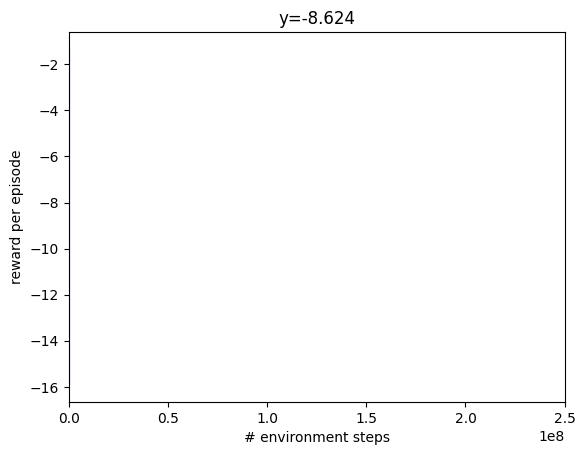

In [ ]:
make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

In [ ]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

In [ ]:
rng = jax.random.PRNGKey(42)
rollout = []
n_episodes = 1

for _ in range(n_episodes):
  state = jit_reset(rng)
  rollout.append(state)
  for i in range(env_cfg.episode_length):
    act_rng, rng = jax.random.split(rng)
    ctrl, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_step(state, ctrl)
    rollout.append(state)

render_every = 1
frames = env.render(rollout[::render_every])
rewards = [s.reward for s in rollout]
media.show_video(frames, fps=1.0 / env.dt / render_every)